In [ ]:
Retail Sales Data Analysis

Author: Tonin Kaipada Thomas  
Tools: Python, Pandas, Matplotlib  
Dataset: Multi-store retail sales dataset

In [14]:
import pandas as pd
import numpy as np

df=pd.read_csv("C:\Data analyst projects\stock sales data 20222023\Data.csv")
df.head()

,item,store_id,2023/1,2023/2,2023/3,2023/4,2023/5,2023/6,2023/7,2023/8,...,2022/3,2022/4,2022/5,2022/6,2022/7,2022/8,2022/9,2022/10,2022/11,2022/12
0,A,1,NaN,NaN,4.0,NaN,5.0,NaN,5.0,NaN,...,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A,2,5.0,NaN,5.0,NaN,NaN,NaN,NaN,5.0,...,5.0,5.0,NaN,6.0,5.0,NaN,2.0,5.0,NaN,NaN
2,A,3,5.0,10.0,50.0,10.0,30.0,10.0,30.0,15.0,...,20.0,35.0,20.0,27.0,21.0,NaN,20.0,15.0,15.0,20.0
3,A,4,20.0,NaN,20.0,NaN,30.0,0.0,NaN,40.0,...,10.0,20.0,10.0,20.0,20.0,NaN,20.0,20.0,NaN,10.0
4,A,5,NaN,20.0,NaN,25.0,20.0,10.0,NaN,20.0,...,10.0,10.0,10.0,10.0,NaN,20.0,NaN,NaN,20.0,5.0


In [15]:
df.shape
df.columns

Index(['item', 'store_id', '2023/1', '2023/2', '2023/3', '2023/4', '2023/5',
       '2023/6', '2023/7', '2023/8', '2023/9', '2022/1', '2022/2', '2022/3',
       '2022/4', '2022/5', '2022/6', '2022/7', '2022/8', '2022/9', '2022/10',
       '2022/11', '2022/12'],
      dtype='object')

In [16]:
id_cols=["item","store_id"]
month_cols=[col for col in df.columns if col not in id_cols]

month_cols[:5]

['2023/1', '2023/2', '2023/3', '2023/4', '2023/5']

In [17]:
df_long = df.melt(
    id_vars=id_cols,
    value_vars=month_cols,
    var_name="month",
    value_name="unit_sales"
)

df_long.head()

,item,store_id,month,unit_sales
0,A,1,2023/1,NaN
1,A,2,2023/1,5.0
2,A,3,2023/1,5.0
3,A,4,2023/1,20.0
4,A,5,2023/1,NaN


In [18]:
df_long.isna().sum()

item              0
store_id          0
month             0
unit_sales    84254
dtype: int64

In [19]:
df_long["unit_sales"]=df_long["unit_sales"].fillna(0)

In [20]:
df_long["month"]=pd.to_datetime(df_long["month"],format="%Y/%m")


In [21]:
df_long.to_csv("C:\Data analyst projects\stock sales data 20222023\Data.csv",index=False)

In [22]:
monthly_sales = (
df_long
    .groupby("month",as_index=False)["unit_sales"]
    .sum()
    .sort_values("month")
)

monthly_sales

,month,unit_sales
0,2022-01-01,13237.0
1,2022-02-01,12212.0
2,2022-03-01,14129.0
3,2022-04-01,48173.0
4,2022-05-01,36138.0
5,2022-06-01,47363.0
6,2022-07-01,41109.0
7,2022-08-01,15498.0
8,2022-09-01,11474.0
9,2022-10-01,16893.0


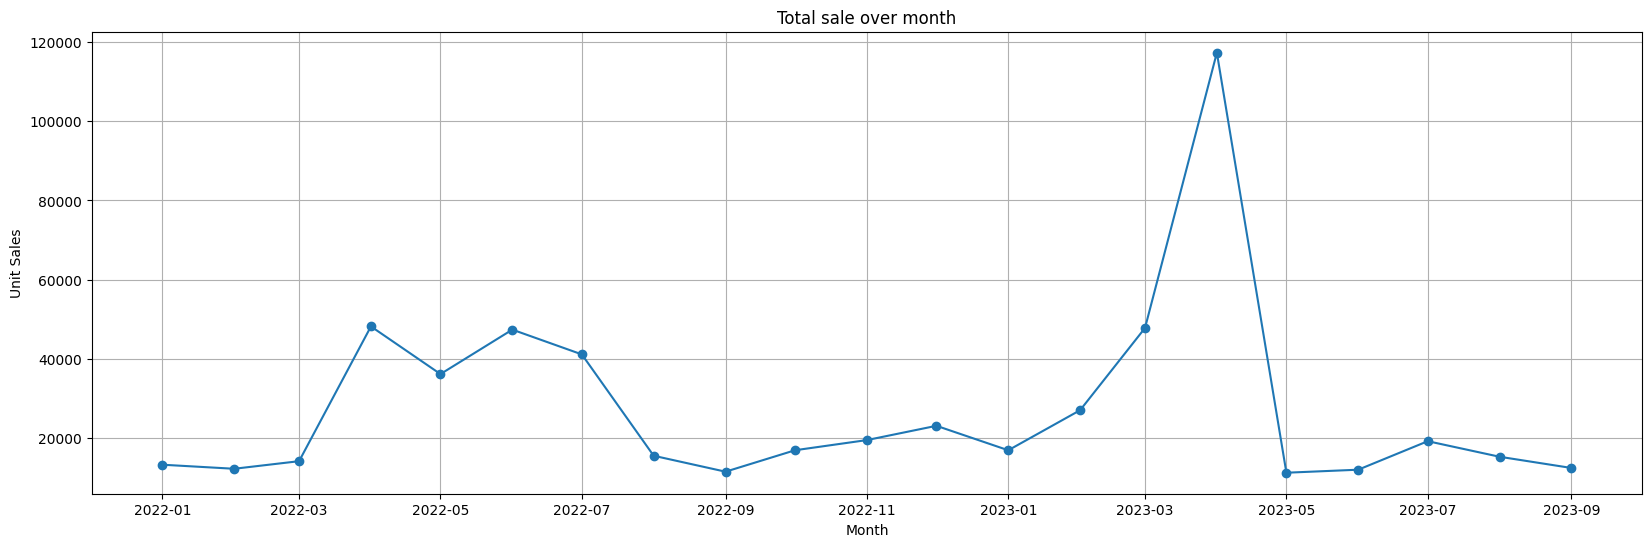

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,6))
plt.plot(monthly_sales["month"], monthly_sales["unit_sales"], marker='o')
plt.title("Total sale over month")
plt.xlabel("Month")
plt.ylabel("Unit Sales")
plt.grid("True")
plt.show()

In [24]:
#top 10 stores by sales
top_stores=(
    df_long
    .groupby("store_id", as_index=False)["unit_sales"]
    .sum()
    .sort_values("unit_sales", ascending=False)
    .head(10)
)

top_stores

,store_id,unit_sales
741,742,28490.0
88,89,20150.0
742,743,15135.0
65,66,12936.0
744,745,12350.0
533,534,11816.0
539,540,8780.0
794,795,8010.0
507,508,7512.0
428,429,7010.0


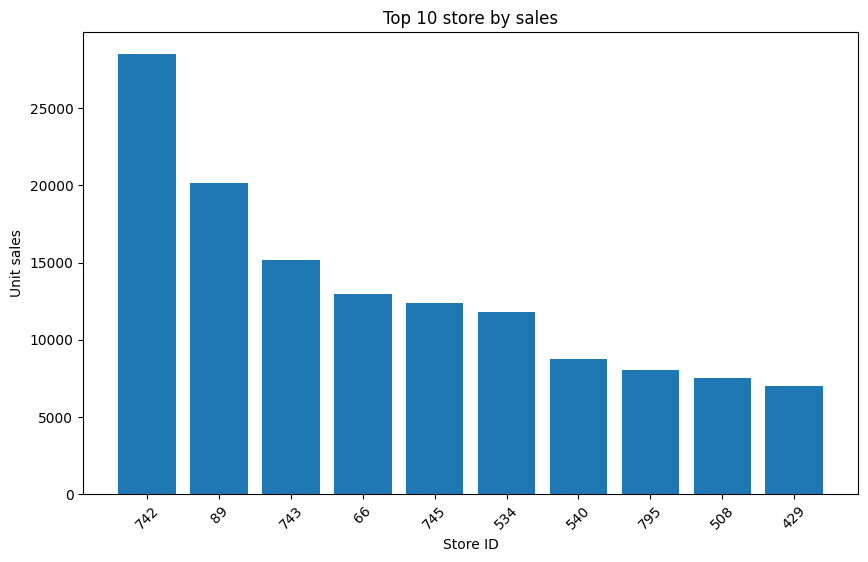

In [25]:
plt.figure(figsize=(10,6))
plt.bar(top_stores["store_id"].astype(str),top_stores["unit_sales"])
plt.title("Top 10 store by sales")
plt.xlabel("Store ID")
plt.ylabel("Unit sales")
plt.xticks(rotation=45)
plt.show()

In [26]:
#Top 10 products by sale
top_products=(
    df_long
    .groupby("item", as_index=False)["unit_sales"]
    .sum()
    .sort_values("unit_sales",ascending=False)
    .head(10)
)

top_products

,item,unit_sales
0,A,165520.0
1,B,159961.0
2,C,124175.0
3,D,78987.0
6,G,24347.0
5,F,10253.0
4,E,9509.0
7,H,5026.0


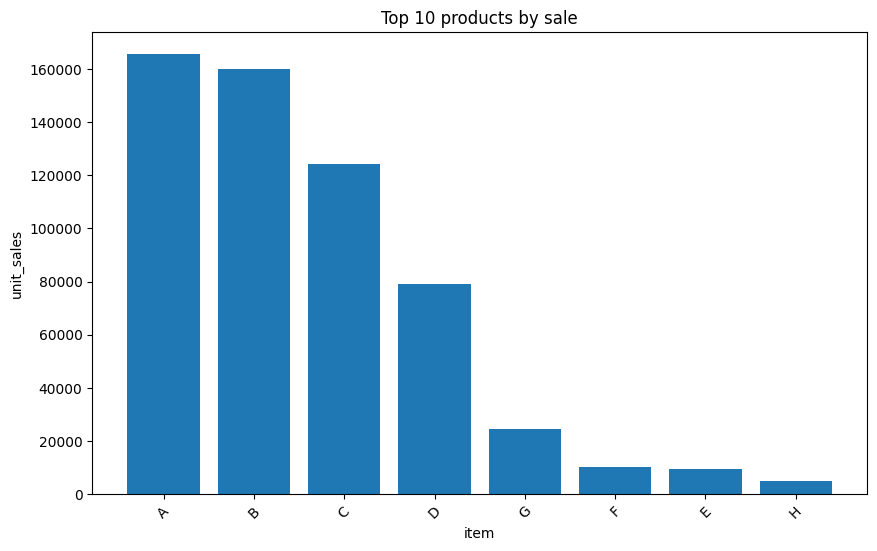

In [27]:
plt.figure(figsize=(10,6))
plt.bar(top_products["item"].astype(str), top_products["unit_sales"])
plt.title("Top 10 products by sale")
plt.xlabel("item")
plt.ylabel("unit_sales")
plt.xticks(rotation=45)
plt.show()

In [28]:
#Sales concentration risk
total_sales= df_long["unit_sales"].sum()
top_10_store_sales=top_stores["unit_sales"].sum()

concentration_ratio = top_10_store_sales/total_sales
concentration_ratio

0.2287885658505516

In [29]:
df_long.head()
df_long.shape

(113253, 4)

In [30]:
import os

os.makedirs("C:\Data analyst projects\stock sales data 20222023\data\processed",exist_ok=True)

In [31]:
df_long.to_csv("C:\Data analyst projects\stock sales data 20222023\data\processed\store_sales_long.csv",index=False)

In [33]:
os.listdir("C:\Data analyst projects\stock sales data 20222023\data\processed")

['Data.csv', 'product_portfolio_analysis.csv', 'store_sales_long.csv']